In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
pd.set_option("display.max_columns", 100)

figures_dir = repo_root / "figures"
reports_dir = repo_root / "reports"

figures_dir.mkdir(exist_ok=True)
reports_dir.mkdir(exist_ok=True)

In [4]:
data_path = repo_root / "data" / "processed" / "alsfrs_longitudinal_week4.csv"
df = pd.read_csv(data_path)

df.head()

,subject_id,alsfrs_delta,alsfrs_r_total
0,3301,5.0,35.0
1,3301,40.0,34.0
2,3301,98.0,32.0
3,3301,161.0,32.0
4,3301,221.0,34.0


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (51903, 3)

Columns:
['subject_id', 'alsfrs_delta', 'alsfrs_r_total']


In [6]:
target_col = "alsfrs_r_total"

candidate_features = [
    "alsfrs_delta",
    "age",
    "sex",
]

available_features = [col for col in candidate_features if col in df.columns]
print("Available features:", available_features)

Available features: ['alsfrs_delta']


In [7]:
model_df = df[available_features + [target_col]].copy()
model_df = model_df.dropna()

print("Modeling shape after dropping missing values:", model_df.shape)
model_df.head()

Modeling shape after dropping missing values: (51903, 2)


,alsfrs_delta,alsfrs_r_total
0,5.0,35.0
1,40.0,34.0
2,98.0,32.0
3,161.0,32.0
4,221.0,34.0


In [8]:
model_df[target_col].describe()

count    51903.000000
mean        32.786062
std          8.639727
min          0.000000
25%         28.000000
50%         34.000000
75%         39.000000
max         48.000000
Name: alsfrs_r_total, dtype: float64

In [9]:
X = model_df[available_features]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (41522, 1)
X_test shape: (10381, 1)


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [11]:
y_pred = rf_model.predict(X_test)
residuals = y_test - y_pred
abs_errors = np.abs(residuals)

In [12]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "value": [rmse, mae, r2]
})

metrics_df

,metric,value
0,RMSE,7.677472
1,MAE,6.121157
2,R2,0.193261


In [13]:
metrics_output_path = reports_dir / "week7_rf_error_analysis_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)

metrics_output_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week7_rf_error_analysis_metrics.csv')

In [14]:
results_df = X_test.copy()
results_df["actual_alsfrs_r_total"] = y_test.values
results_df["predicted_alsfrs_r_total"] = y_pred
results_df["residual"] = residuals.values
results_df["absolute_error"] = abs_errors

results_df.head()

,alsfrs_delta,actual_alsfrs_r_total,predicted_alsfrs_r_total,residual,absolute_error
30263,301.0,40.0,29.532417,10.467583,10.467583
25889,412.0,21.0,28.093388,-7.093388,7.093388
30398,43.0,41.0,36.626107,4.373893,4.373893
16889,289.0,32.0,30.430910,1.569090,1.569090
23873,82.0,39.0,34.687047,4.312953,4.312953


In [15]:
results_df["residual"].describe()

count    10381.000000
mean         0.078320
std          7.677442
min        -31.744014
25%         -4.867948
50%          0.921863
75%          5.492832
max         26.989459
Name: residual, dtype: float64

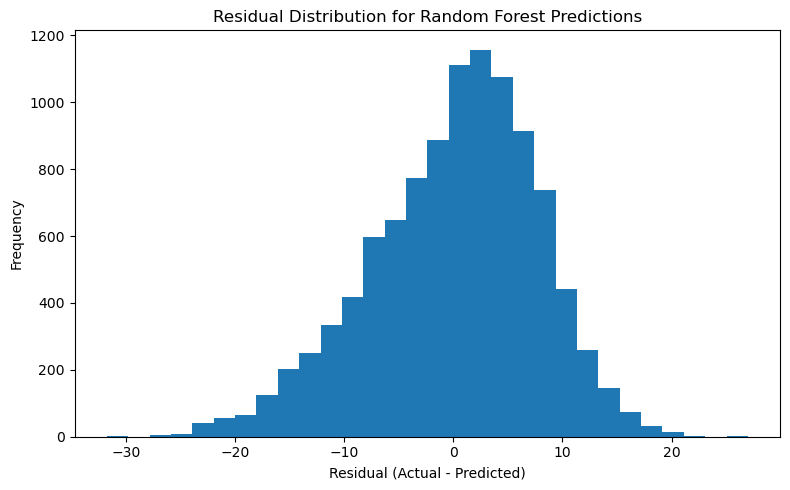

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/figures/week7_residual_distribution_rf.png')

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(results_df["residual"], bins=30)
plt.title("Residual Distribution for Random Forest Predictions")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()

residual_hist_path = figures_dir / "week7_residual_distribution_rf.png"
plt.savefig(residual_hist_path, dpi=300, bbox_inches="tight")
plt.show()

residual_hist_path

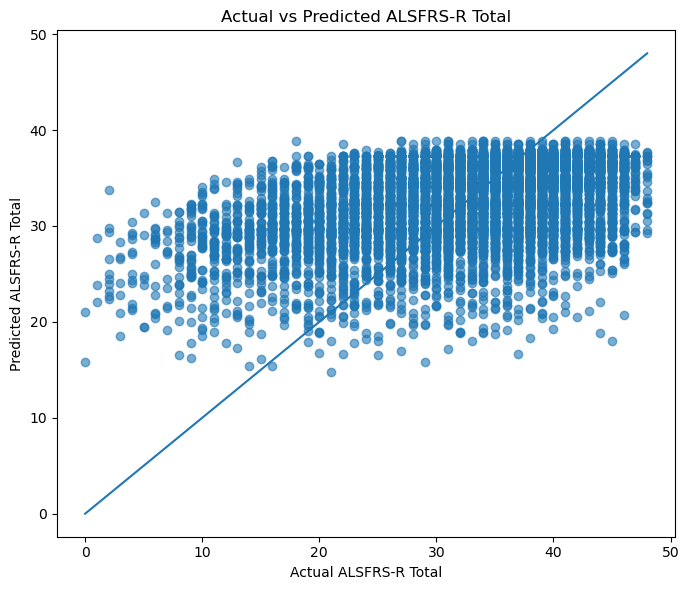

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/figures/week7_actual_vs_predicted_rf_refined.png')

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(results_df["actual_alsfrs_r_total"], results_df["predicted_alsfrs_r_total"], alpha=0.6)

min_val = min(results_df["actual_alsfrs_r_total"].min(), results_df["predicted_alsfrs_r_total"].min())
max_val = max(results_df["actual_alsfrs_r_total"].max(), results_df["predicted_alsfrs_r_total"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.title("Actual vs Predicted ALSFRS-R Total")
plt.xlabel("Actual ALSFRS-R Total")
plt.ylabel("Predicted ALSFRS-R Total")
plt.tight_layout()

actual_vs_pred_path = figures_dir / "week7_actual_vs_predicted_rf_refined.png"
plt.savefig(actual_vs_pred_path, dpi=300, bbox_inches="tight")
plt.show()

actual_vs_pred_path

In [19]:
if "alsfrs_delta" in results_df.columns:
    results_df["alsfrs_delta_bin"] = pd.cut(results_df["alsfrs_delta"], bins=4)

    error_by_delta = (
        results_df.groupby("alsfrs_delta_bin", observed=False)["absolute_error"]
        .agg(["mean", "median", "count"])
        .reset_index()
    )

    error_by_delta

In [20]:
if "alsfrs_delta_bin" in results_df.columns:
    error_by_delta_path = reports_dir / "week7_error_by_delta_bin.csv"
    error_by_delta.to_csv(error_by_delta_path, index=False)
    error_by_delta_path

In [21]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
0,alsfrs_delta,1.0


In [22]:
feature_importance_path = reports_dir / "week7_rf_feature_importance_refined.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

feature_importance_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week7_rf_feature_importance_refined.csv')

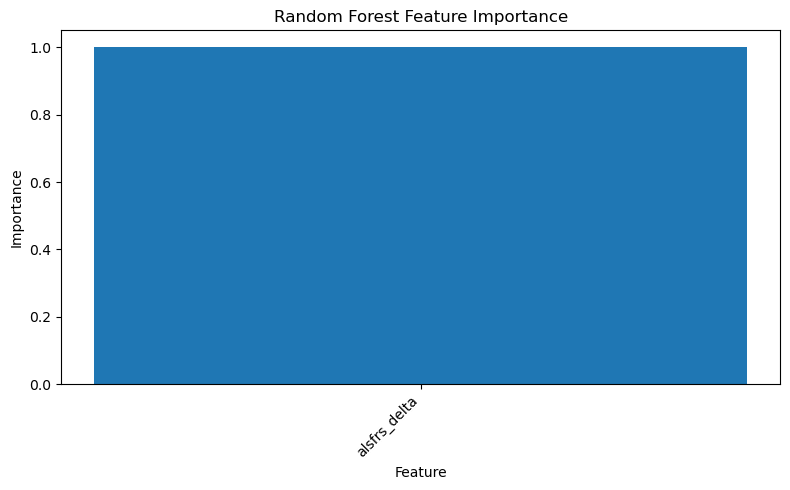

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/figures/week7_rf_feature_importance_refined.png')

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

feature_importance_fig_path = figures_dir / "week7_rf_feature_importance_refined.png"
plt.savefig(feature_importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

feature_importance_fig_path

In [24]:
worst_cases_df = results_df.sort_values("absolute_error", ascending=False).head(15)
worst_cases_df

,alsfrs_delta,actual_alsfrs_r_total,predicted_alsfrs_r_total,residual,absolute_error,alsfrs_delta_bin
44614,115.0,2.0,33.744014,-31.744014,31.744014,"(-87.08, 435.0]"
43714,272.0,2.0,29.764911,-27.764911,27.764911,"(-87.08, 435.0]"
3858,277.0,1.0,28.700809,-27.700809,27.700809,"(-87.08, 435.0]"
37339,428.0,2.0,29.347690,-27.347690,27.347690,"(-87.08, 435.0]"
4894,1035.0,45.0,18.010541,26.989459,26.989459,"(955.0, 1475.0]"
9532,-1.0,6.0,32.533993,-26.533993,26.533993,"(-87.08, 435.0]"
25932,241.0,4.0,30.385476,-26.385476,26.385476,"(-87.08, 435.0]"
26803,268.0,5.0,31.368152,-26.368152,26.368152,"(-87.08, 435.0]"
9266,350.0,3.0,28.296799,-25.296799,25.296799,"(-87.08, 435.0]"
34357,782.0,46.0,20.718129,25.281871,25.281871,"(435.0, 955.0]"


In [25]:
worst_cases_path = reports_dir / "week7_worst_predicted_cases.csv"
worst_cases_df.to_csv(worst_cases_path, index=False)

worst_cases_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week7_worst_predicted_cases.csv')

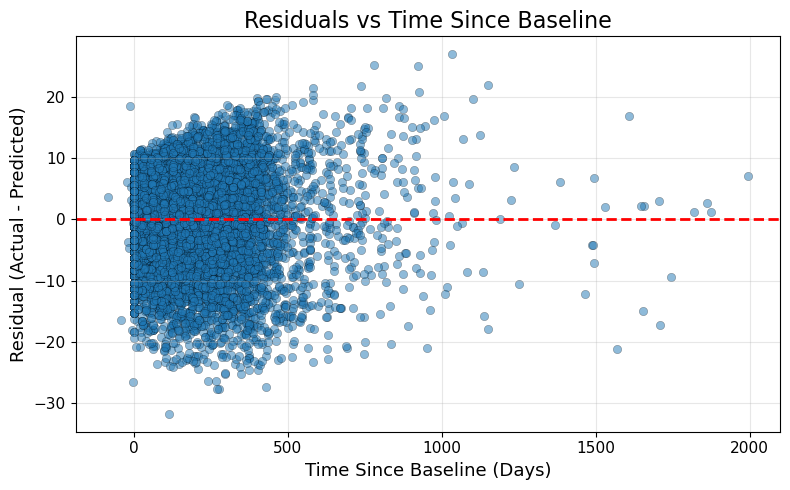

In [27]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    X_test["alsfrs_delta"], 
    residuals, 
    alpha=0.5,
    edgecolor='black',
    linewidth=0.3
)

plt.axhline(0, linestyle="--", color="red", linewidth=2)

plt.title("Residuals vs Time Since Baseline", fontsize=16)
plt.xlabel("Time Since Baseline (Days)", fontsize=13)
plt.ylabel("Residual (Actual - Predicted)", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/demo_residuals_vs_time.png", dpi=300)
plt.show()